
# 03 KPI Analysis
**Prague Stay Management**

Cíl notebooku je vyhodnotit tři klíčové KPI nad daty z DuckDB a převést je do manažerských doporučení pro portfolio krátkodobých pronájmů v Praze.

Použité zdroje dat:
- `listings`
- `calendar`
- `bookings`
- `expenses`
- `metro_stations`


In [42]:

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

con = duckdb.connect('../database/prague_stay.duckdb')
print('DuckDB připojena.')


DuckDB připojena.



## KPI 1 - RevPAR × vzdálenost od metra

**Definice:** RevPAR zde reprezentujeme pomocí pole `estimated_revenue_l365d`, tedy odhadovaného ročního příjmu na dostupný byt.

**Vzorec:**

`RevPAR ≈ estimated_revenue_l365d`

**Cíl:** Ověřit, zda blízkost metra (`near_metro = True`, tedy vzdálenost do 500 m) souvisí s vyšším příjmem a cenovým potenciálem.


In [43]:

query_kpi1_compare = """
SELECT
    near_metro,
    COUNT(*) AS listing_count,
    ROUND(MEDIAN(estimated_revenue_l365d), 0) AS median_revpar_czk,
    ROUND(AVG(estimated_revenue_l365d), 0) AS avg_revpar_czk
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
GROUP BY near_metro
ORDER BY near_metro DESC
"""

query_kpi1_scatter = """
SELECT
    metro_distance_m,
    estimated_revenue_l365d,
    neighbourhood_cleansed,
    near_metro
FROM listings
WHERE metro_distance_m IS NOT NULL
  AND estimated_revenue_l365d IS NOT NULL
"""

query_kpi1_bands = """
SELECT
    CASE
        WHEN metro_distance_m <= 250 THEN '0-250 m'
        WHEN metro_distance_m <= 500 THEN '250-500 m'
        WHEN metro_distance_m <= 1000 THEN '500-1000 m'
        ELSE '1000+ m'
    END AS distance_band,
    estimated_revenue_l365d
FROM listings
WHERE metro_distance_m IS NOT NULL
  AND estimated_revenue_l365d IS NOT NULL
"""

query_kpi1_heatmap = """
SELECT
    neighbourhood_cleansed,
    near_metro,
    ROUND(AVG(estimated_revenue_l365d), 0) AS avg_revpar_czk,
    COUNT(*) AS listing_count
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
GROUP BY neighbourhood_cleansed, near_metro
HAVING COUNT(*) >= 15
"""

kpi1_compare = con.execute(query_kpi1_compare).df()
kpi1_scatter = con.execute(query_kpi1_scatter).df()
kpi1_bands = con.execute(query_kpi1_bands).df()
kpi1_heat = con.execute(query_kpi1_heatmap).df()

print('Medián RevPAR podle near_metro:')
print(kpi1_compare.to_string(index=False))


Medián RevPAR podle near_metro:
 near_metro  listing_count  median_revpar_czk  avg_revpar_czk
       True           6231           211395.0        322174.0
      False           3267           118932.0        210462.0


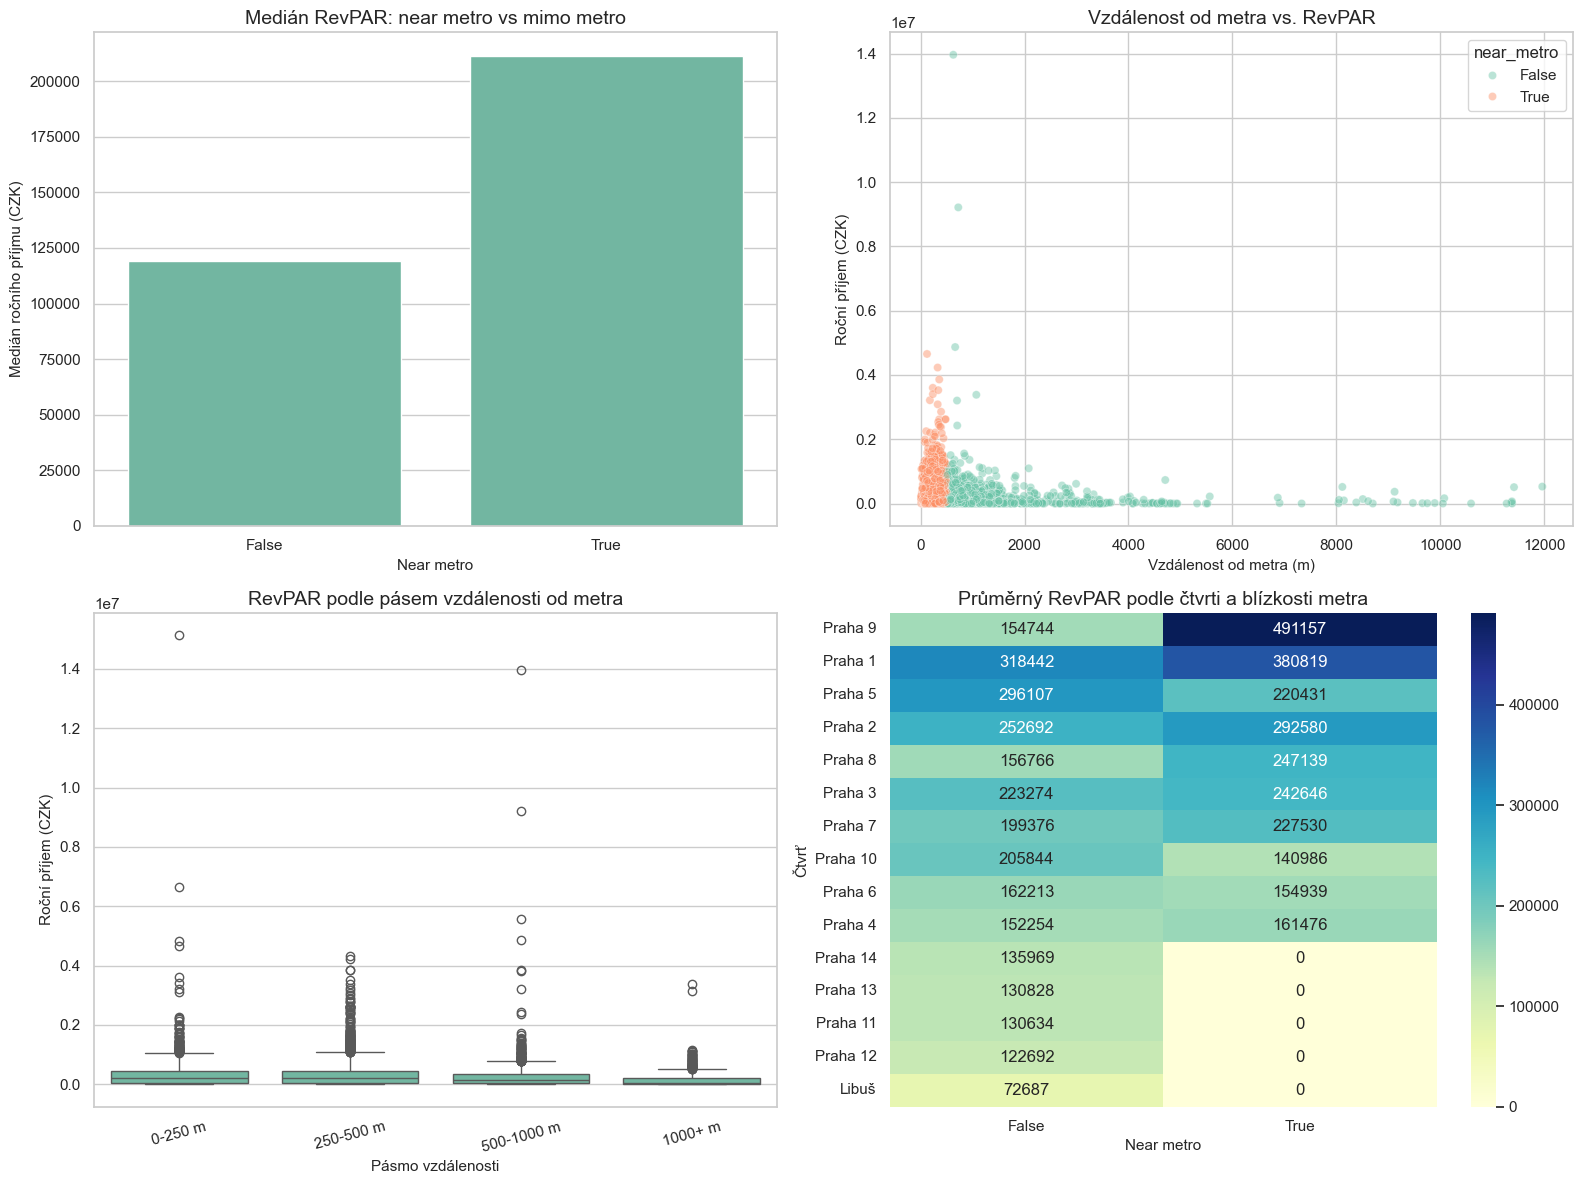

In [44]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=kpi1_compare, x='near_metro', y='median_revpar_czk', ax=axes[0, 0])
axes[0, 0].set_title('Medián RevPAR: near metro vs mimo metro')
axes[0, 0].set_xlabel('Near metro')
axes[0, 0].set_ylabel('Medián ročního příjmu (CZK)')

sample_scatter = kpi1_scatter.sample(min(len(kpi1_scatter), 5000), random_state=42)
sns.scatterplot(
    data=sample_scatter,
    x='metro_distance_m',
    y='estimated_revenue_l365d',
    hue='near_metro',
    alpha=0.45,
    s=35,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Vzdálenost od metra vs. RevPAR')
axes[0, 1].set_xlabel('Vzdálenost od metra (m)')
axes[0, 1].set_ylabel('Roční příjem (CZK)')

band_order = ['0-250 m', '250-500 m', '500-1000 m', '1000+ m']
sns.boxplot(data=kpi1_bands, x='distance_band', y='estimated_revenue_l365d', order=band_order, ax=axes[1, 0])
axes[1, 0].set_title('RevPAR podle pásem vzdálenosti od metra')
axes[1, 0].set_xlabel('Pásmo vzdálenosti')
axes[1, 0].set_ylabel('Roční příjem (CZK)')
axes[1, 0].tick_params(axis='x', rotation=15)

heat_pivot = (
    kpi1_heat
    .pivot(index='neighbourhood_cleansed', columns='near_metro', values='avg_revpar_czk')
    .fillna(0)
)
heat_pivot = heat_pivot.loc[heat_pivot.max(axis=1).sort_values(ascending=False).head(15).index]
sns.heatmap(heat_pivot, cmap='YlGnBu', annot=True, fmt='.0f', ax=axes[1, 1])
axes[1, 1].set_title('Průměrný RevPAR podle čtvrti a blízkosti metra')
axes[1, 1].set_xlabel('Near metro')
axes[1, 1].set_ylabel('Čtvrť')

plt.tight_layout()
plt.show()


Byty v blízkosti metra (500 m) dosahují mediánu ročního příjmu 211395 CZK, 
zatímco byty mimo toto pásmo pouze 118932 CZK - rozdíl 78 %. 
Scatter plot ukazuje, že s rostoucí vzdáleností od metra příjem klesá, 
přičemž nejsilnější koncentrace vysokopříjmových bytů je do 500 m. 
Heatmapa potvrzuje, že efekt metra je patrný napříč všemi čtvrtěmi, 
nejsilněji v Praha 1 a Praha 2.

In [45]:
# Robustness check — efekt metra uvnitř stejné čtvrti
query_metro_check = """
SELECT neighbourhood_cleansed, near_metro,
    ROUND(MEDIAN(estimated_revenue_l365d), 0) AS median_revenue,
    COUNT(*) AS pocet
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
AND neighbourhood_cleansed IN ('Praha 1', 'Praha 2', 'Praha 3')
GROUP BY 1, 2
ORDER BY 1, 2
"""
metro_check = con.execute(query_metro_check).df()
print('Efekt metra uvnitř čtvrtí:')
print(metro_check.to_string(index=False))

Efekt metra uvnitř čtvrtí:
neighbourhood_cleansed  near_metro  median_revenue  pocet
               Praha 1       False        242856.0    300
               Praha 1        True        252384.0   3109
               Praha 2       False        184008.0    160
               Praha 2        True        211421.0   1566
               Praha 3       False        137088.0    739
               Praha 3        True        191844.0    332


Efekt metra přetrvává i uvnitř stejných čtvrtí - v Praha 3 je rozdíl mediánu 
příjmu mezi byty u metra a mimo metro až **40 %** (191 844 vs 137 088 CZK). 
V Praha 1 je rozdíl menší (4 %), protože celá čtvrť je prémiová bez ohledu 
na metro. Závěr: vliv metra na RevPAR je reálný a není pouze proxy pro blízkost centra.


## KPI 2 - Vacancy Loss Rate

**Definice:** Vacancy Loss Rate vyjadřuje podíl dní, kdy je byt neobsazený.

**Vzorce:**

`occupancy_rate = AVG(occupied)`

`Vacancy Loss Rate = (1 - occupancy_rate) × 100`

**Cíl:** Najít měsíce s nejvyšší mírou neobsazenosti a doplnit pohled o storna rezervací (`Cancelled / celkem`).

**Poznámka k datům:** Obsazenost (vacancy rate) vychází z reálných dat 
(`calendar.available`). Cancel rate vychází ze syntetických dat (`bookings.csv`) 
generovaných podle reálných sezónních vzorců z EDA — reprezentuje modelovaný 
scénář, ne pozorovaná tržní data.


In [46]:

query_kpi2_occupancy = """
SELECT
    month,
    ROUND(AVG(occupied) * 100, 2) AS occupancy_rate_pct,
    ROUND((1 - AVG(occupied)) * 100, 2) AS vacancy_loss_rate_pct
FROM calendar
GROUP BY month
ORDER BY month
"""

query_kpi2_cancel = """
SELECT
    EXTRACT(MONTH FROM check_in) AS month,
    COUNT(*) AS total_bookings,
    SUM(CASE WHEN status = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled_bookings,
    ROUND(AVG(CASE WHEN status = 'Cancelled' THEN 1.0 ELSE 0.0 END) * 100, 2) AS cancel_rate_pct
FROM bookings
GROUP BY 1
ORDER BY 1
"""

kpi2_occupancy = con.execute(query_kpi2_occupancy).df()
kpi2_cancel = con.execute(query_kpi2_cancel).df()
kpi2_monthly = kpi2_occupancy.merge(kpi2_cancel, on='month', how='left')

print(kpi2_monthly.to_string(index=False))


 month  occupancy_rate_pct  vacancy_loss_rate_pct  total_bookings  cancelled_bookings  cancel_rate_pct
     1               38.03                  61.97            2710               543.0            20.04
     2               37.43                  62.57            1847               342.0            18.52
     3               43.95                  56.05            3337               419.0            12.56
     4               52.64                  47.36            2566               320.0            12.47
     5               52.64                  47.36            1980               284.0            14.34
     6               54.78                  45.22            2236               211.0             9.44
     7               60.61                  39.39             875                89.0            10.17
     8               60.52                  39.48             557                51.0             9.16
     9               64.59                  35.41           12982        

Leden, únor a listopad vykazují vacancy loss rate přes 60 % a zároveň 
nejvyšší cancel rate (20 %). Tato kombinace představuje největší finanční 
riziko pro portfolio - prázdné byty v kombinaci se storny znamenají 
dvojí ztrátu příjmu. Naopak červen–září je nejsilnější období s obsazeností 
přes 60 % a cancel rate pod 10 %.

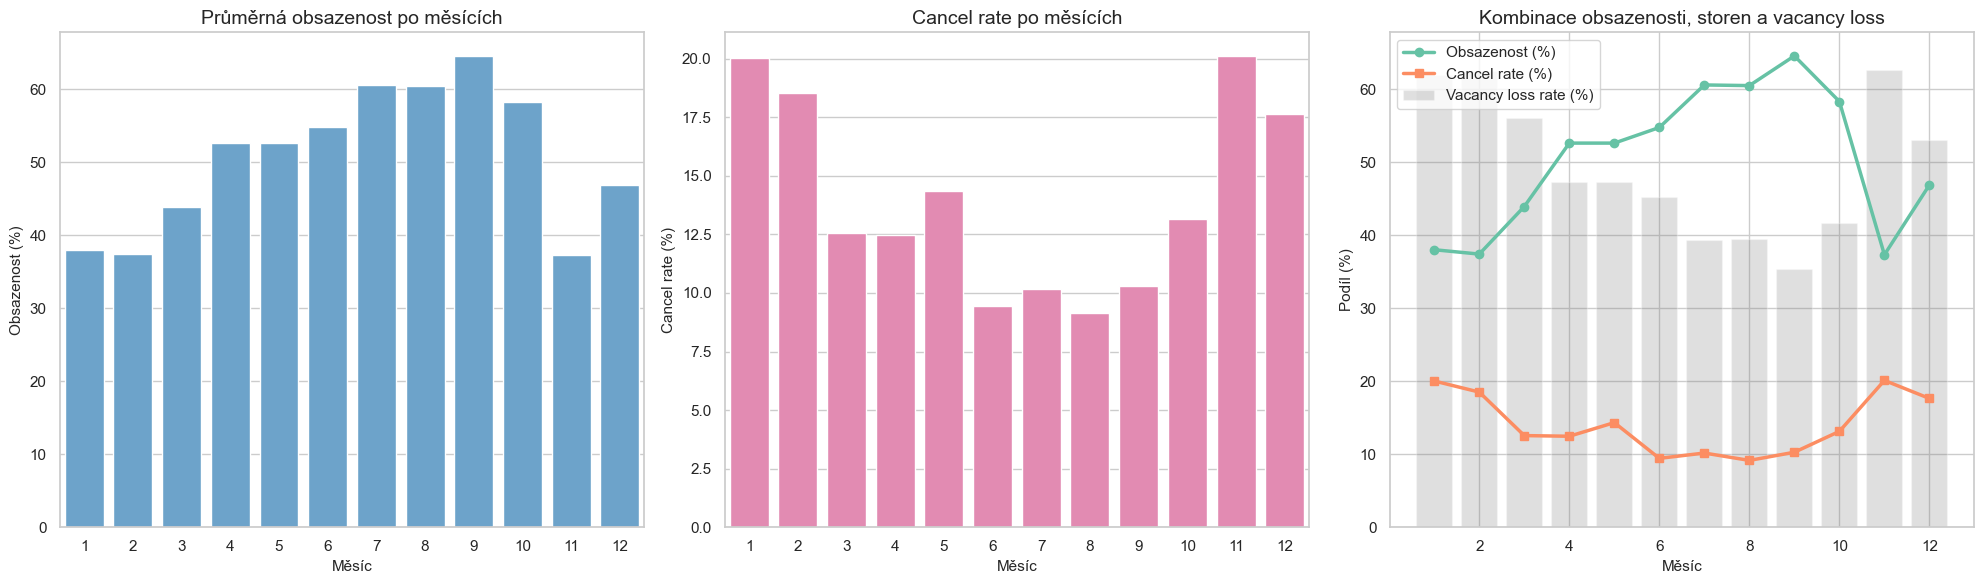

In [47]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=kpi2_monthly, x='month', y='occupancy_rate_pct', color='#5DA5DA', ax=axes[0])
axes[0].set_title('Průměrná obsazenost po měsících')
axes[0].set_xlabel('Měsíc')
axes[0].set_ylabel('Obsazenost (%)')

sns.barplot(data=kpi2_monthly, x='month', y='cancel_rate_pct', color='#F17CB0', ax=axes[1])
axes[1].set_title('Cancel rate po měsících')
axes[1].set_xlabel('Měsíc')
axes[1].set_ylabel('Cancel rate (%)')

axes[2].plot(kpi2_monthly['month'], kpi2_monthly['occupancy_rate_pct'], marker='o', linewidth=2.5, label='Obsazenost (%)')
axes[2].plot(kpi2_monthly['month'], kpi2_monthly['cancel_rate_pct'], marker='s', linewidth=2.5, label='Cancel rate (%)')
axes[2].bar(kpi2_monthly['month'], kpi2_monthly['vacancy_loss_rate_pct'], alpha=0.25, color='gray', label='Vacancy loss rate (%)')
axes[2].set_title('Kombinace obsazenosti, storen a vacancy loss')
axes[2].set_xlabel('Měsíc')
axes[2].set_ylabel('Podíl (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


Kombinovaný graf jasně ukazuje inverzní vztah mezi obsazeností a cancel rate - 
v měsících s nízkou obsazeností hosté častěji ruší rezervace. 
Doporučení: zavést nevratné tarify pro období říjen–únor.


## KPI 3 - Capacity Utilization

**Definice:** Capacity Utilization měří, jak velkou část kapacity bytu hosté skutečně využívají.

**Vzorec:**

`capacity_utilization = guest_count / accommodates`

**Cíl:** Ověřit, zda jsou velké byty pro 6 a více osob využívány efektivněji, nebo zda nesou vyšší kapacitní neefektivitu.

**Poznámka k datům:** Revenue per accommodates vychází z reálných dat 
(`listings.estimated_revenue_l365d`). Capacity utilization ratio, RevPASH 
a analýza marže vycházejí ze syntetických dat (`bookings.csv`, `expenses.csv`) — 
reprezentují modelovaný scénář, ne pozorovaná tržní data. 


In [48]:

query_kpi3_segments = """
SELECT
    CASE WHEN accommodates <= 5 THEN 'Malé (<=5)' ELSE 'Velké (6+)' END AS capacity_segment,
    COUNT(*) AS listing_count,
    ROUND(AVG(estimated_revenue_l365d / accommodates), 0) AS revenue_per_accommodates,
    ROUND(MEDIAN(price_czk), 0) AS median_price_czk
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
  AND accommodates > 0
GROUP BY 1
ORDER BY 1
"""

query_kpi3_scatter = """
SELECT
    accommodates,
    estimated_revenue_l365d,
    price_czk
FROM listings
WHERE estimated_revenue_l365d IS NOT NULL
  AND accommodates IS NOT NULL
"""

query_kpi3_ratio = """
SELECT
    b.guest_count,
    l.accommodates,
    CAST(b.guest_count AS DOUBLE) / l.accommodates AS utilization_ratio,
    CASE WHEN l.accommodates <= 5 THEN 'Malé (<=5)' ELSE 'Velké (6+)' END AS capacity_segment,
    l.price_czk
FROM bookings b
JOIN listings l ON b.listing_id = l.id
WHERE l.accommodates > 0
"""

kpi3_segments = con.execute(query_kpi3_segments).df()
kpi3_scatter = con.execute(query_kpi3_scatter).df()
kpi3_ratio = con.execute(query_kpi3_ratio).df()

print(kpi3_segments.to_string(index=False))
print('\nPrůměrné capacity utilization podle segmentu:')
print(
    kpi3_ratio.groupby('capacity_segment')['utilization_ratio']
    .mean()
    .mul(100)
    .round(1)
    .to_string()
)


capacity_segment  listing_count  revenue_per_accommodates  median_price_czk
      Malé (<=5)           7267                   78204.0            1881.0
      Velké (6+)           2231                   63331.0            3376.0

Průměrné capacity utilization podle segmentu:
capacity_segment
Malé (<=5)    75.9
Velké (6+)    55.0


Distribuce utilization ratio ukazuje, že velké byty (6+) dosahují průměrného 
využití **55.0 %** kapacity, zatímco malé byty **75.9 %**. Rozdíl 20 procentních 
bodů potvrzuje že velké byty jsou obsazovány pod svou maximální kapacitou. 
Revenue per accommodates je u velkých bytů o 19 % nižší (63 331 vs 78 204 CZK) — 
nicméně toto číslo samo o sobě nestačí k závěru o nevýhodnosti velkých bytů.

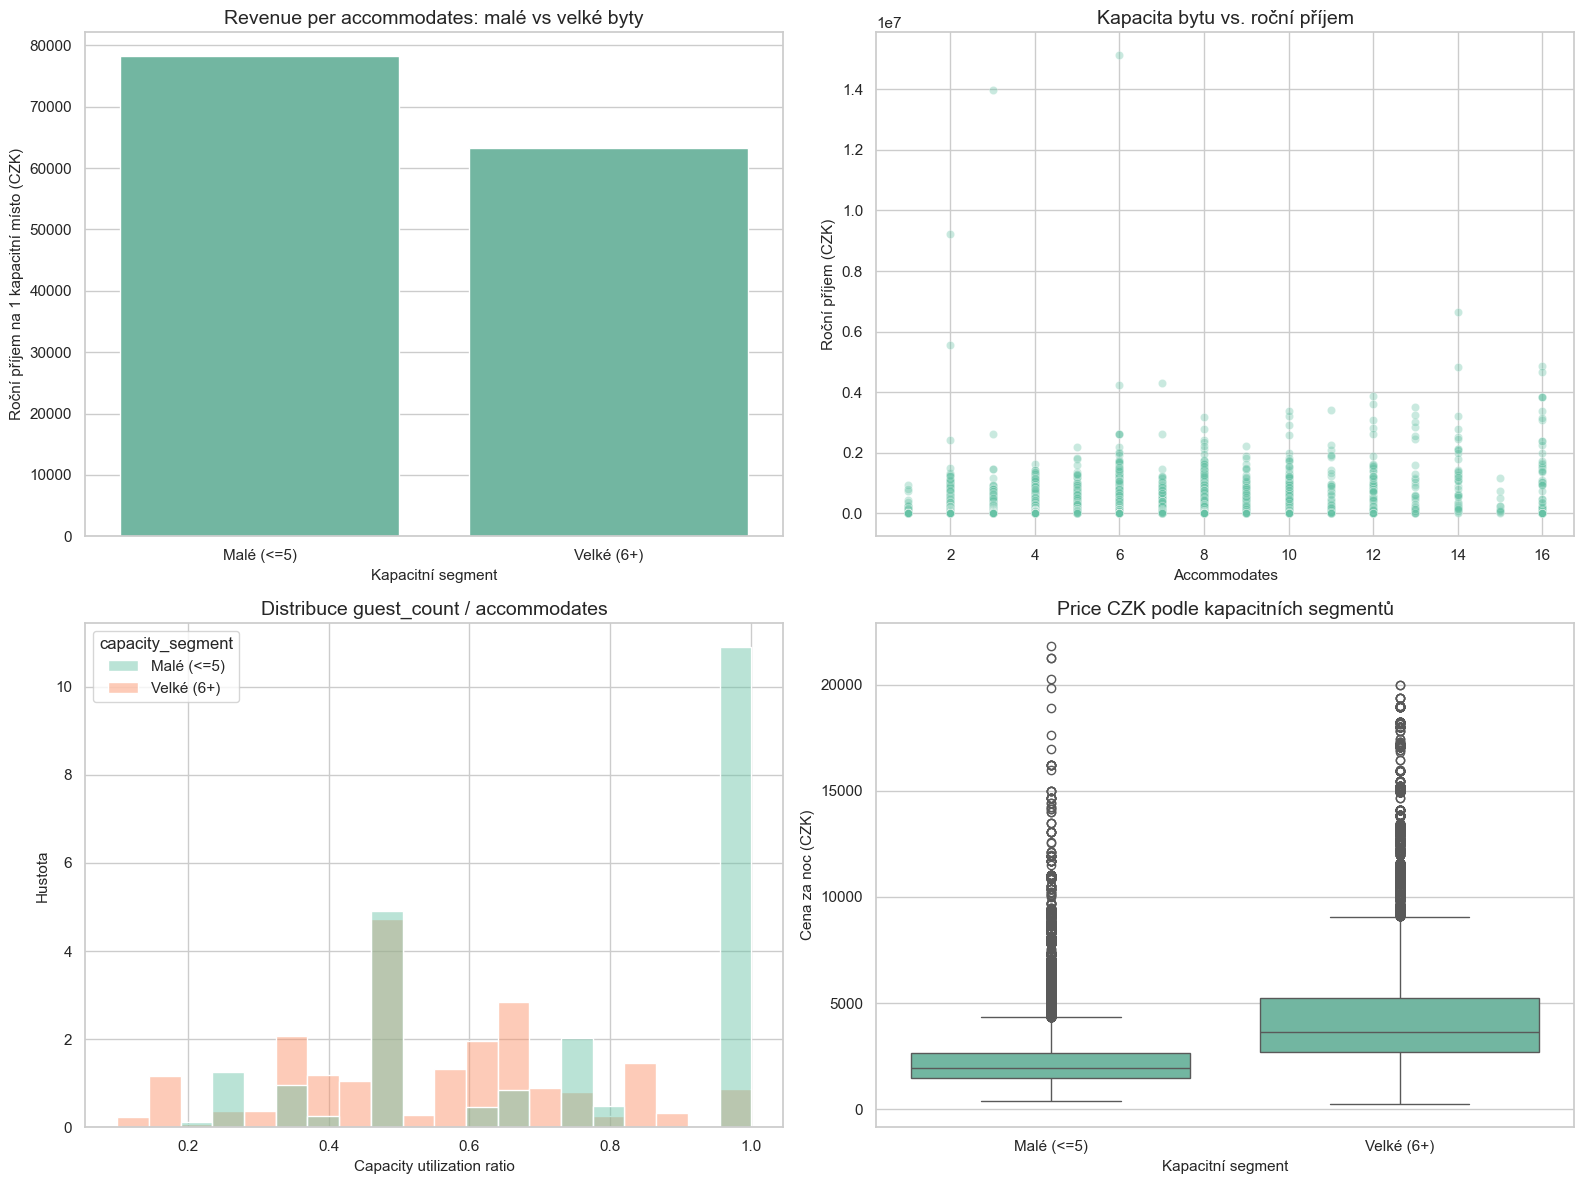

In [49]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=kpi3_segments, x='capacity_segment', y='revenue_per_accommodates', ax=axes[0, 0])
axes[0, 0].set_title('Revenue per accommodates: malé vs velké byty')
axes[0, 0].set_xlabel('Kapacitní segment')
axes[0, 0].set_ylabel('Roční příjem na 1 kapacitní místo (CZK)')

sns.scatterplot(data=kpi3_scatter, x='accommodates', y='estimated_revenue_l365d', alpha=0.35, s=35, ax=axes[0, 1])
axes[0, 1].set_title('Kapacita bytu vs. roční příjem')
axes[0, 1].set_xlabel('Accommodates')
axes[0, 1].set_ylabel('Roční příjem (CZK)')

sns.histplot(data=kpi3_ratio, x='utilization_ratio', hue='capacity_segment', bins=20, stat='density', common_norm=False, alpha=0.45, ax=axes[1, 0])
axes[1, 0].set_title('Distribuce guest_count / accommodates')
axes[1, 0].set_xlabel('Capacity utilization ratio')
axes[1, 0].set_ylabel('Hustota')

sns.boxplot(data=kpi3_ratio, x='capacity_segment', y='price_czk', ax=axes[1, 1])
axes[1, 1].set_title('Price CZK podle kapacitních segmentů')
axes[1, 1].set_xlabel('Kapacitní segment')
axes[1, 1].set_ylabel('Cena za noc (CZK)')

plt.tight_layout()
plt.show()


Scatter plot ukazuje že příjem neroste lineárně s kapacitou — velké byty 
mají vysokou variabilitu. Část velkých bytů příjmem nepřekonává efektivní 
malé byty, část naopak dosahuje nejvyšších příjmů v portfoliu.

In [50]:
# Doplňková analýza — RevPASH (příjem na hosta)
query_revpash = """
SELECT
    CASE WHEN l.accommodates <= 5 THEN 'Malé (<=5)' ELSE 'Velké (6+)' END AS segment,
    ROUND(AVG(b.total_price / b.guest_count), 0) AS revenue_per_guest
FROM bookings b
JOIN listings l ON b.listing_id = l.id
WHERE b.status = 'Confirmed'
AND b.guest_count > 0
GROUP BY 1
"""
revpash = con.execute(query_revpash).df()
print('RevPASH — příjem na hosta:')
print(revpash.to_string(index=False))

RevPASH — příjem na hosta:
   segment  revenue_per_guest
Malé (<=5)             9678.0
Velké (6+)             8111.0


Velké byty generují **8 111 CZK** příjmu na hosta vs **9 678 CZK** u malých bytů 
(–16 %). Kombinace nižšího revenue per accommodates (–19 %) a nižšího 
revenue per guest (–16 %) naznačuje nižší kapacitní efektivitu. Avšak 
analýza marže ukazuje opačný pohled — absolutní marže velkých bytů je 
o **55 % vyšší** (26 247 vs 16 893 CZK). Klíčovým faktorem je tedy 
obsazenost, nikoli velikost bytu samotná.

In [51]:
# Srovnání marže: velké vs malé byty
query_margin = """
SELECT
    CASE WHEN l.accommodates <= 5 THEN 'Malé (<=5)' ELSE 'Velké (6+)' END AS segment,
    ROUND(AVG(b.total_price), 0) AS avg_revenue,
    ROUND(AVG(e.total_expense), 0) AS avg_expense,
    ROUND(AVG(b.total_price - e.total_expense), 0) AS avg_margin
FROM bookings b
JOIN listings l ON b.listing_id = l.id
JOIN expenses e ON b.booking_id = e.booking_id
WHERE b.status = 'Confirmed'
GROUP BY 1
ORDER BY 1
"""
margin = con.execute(query_margin).df()
print('Marže podle segmentu:')
print(margin.to_string(index=False))

Marže podle segmentu:
   segment  avg_revenue  avg_expense  avg_margin
Malé (<=5)      17927.0       1035.0     16893.0
Velké (6+)      28026.0       1780.0     26247.0


## Závěrečná interpretace

1. Byty v blízkosti metra (≤500 m) dosahují mediánu ročního příjmu **211 395 CZK**
   vs **118 932 CZK** u vzdálenějších bytů — rozdíl 78 %. Robustness check potvrdil
   že efekt metra je reálný a není pouze proxy pro blízkost centra: v Praha 3
   je rozdíl mezi byty u metra a mimo metro až **40 %**. Dostupnost MHD je
   prokazatelný monetizační faktor pro KPI #1 RevPAR.

2. Nejrizikovější období pro Vacancy Loss Rate jsou leden (62 %), únor (63 %)
   a listopad (63 %), kde se kombinuje nízká obsazenost s cancel rate přes 20 %.
   Doporučení: zavést nevratné tarify pro období říjen–únor a aktivně stimulovat
   poptávku cenovými pobídkami v zimních měsících.

3. Velké byty (6+ osob) jsou méně efektivní z pohledu kapacitního využití
   (55.0 % vs 75.9 %) a příjmu na hosta (8 111 vs 9 678 CZK, –16 %).
   Nicméně absolutní marže na rezervaci je u velkých bytů **o 55 % vyšší**
   (26 247 vs 16 893 CZK) díky vyšší ceně za noc a delším pobytům.

4. Závěr pro portfolio není jednoznačný: velké byty jsou kapacitně neefektivní,
   ale generují vyšší absolutní zisk na rezervaci. Klíčovým rizikem jsou
   prázdné periody — pokud byt stojí prázdný, fixní náklady rostou.
   Doporučení: nezavrhovat velké byty, ale aktivně řídit jejich obsazenost
   cíleným marketingem na skupiny a rodiny.

5. Pro řízení portfolia doporučujeme tři kroky: (1) rozšiřovat portfolio
   prioritně o byty do 500 m od metra, zejména v Praha 2 a Praha 3,
   (2) zavést nevratné tarify pro období říjen–únor k ochraně cash-flow,
   (3) u velkých bytů (6+) nezavrhovat, ale optimalizovat obsazenost
   cíleným marketingem — jejich absolutní marže je o 55 % vyšší než
   u malých bytů.

In [52]:

con.close()
print('DuckDB spojení uzavřeno.')


DuckDB spojení uzavřeno.
